<a href="https://colab.research.google.com/github/Cyber-GenAI/agent_attack_nlp/blob/main/RoboFirewall_final_unified_evaluation_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERBERUS — Final Unified Evaluation (bug-fixed)

**Single source of truth for the paper’s experimental section.**
This notebook merges Phase-4 calibration/diagnostics with Phase-5.1 end-to-end evaluation
and applies every correctness fix identified in architectural and runtime review.

## Runtime / correctness fixes in this revision

| # | Bug | Impact | Fix |
|---|-----|--------|-----|
| 1 | Texts shorter than 40 chars never entered the cascade | Silent pass → under-counted interception / FPR | End-of-stream flush (`is_last`) forces a final check |
| 2 | `reached_layer3` used the *accumulated* trace | Prefix L3 visits polluted Req. 7 | Use `decided_by == "layer3_judge"` (current cycle) |
| 3 | `temperature=0.0` + `do_sample=False` | `ValueError` on transformers ≥4.46 | Omit `temperature` when greedy |
| 4 | `apply_chat_template` tensor vs dict | `inputs.shape` crash | Normalize to `input_ids` + `attention_mask` |
| 5 | `InMemorySaver` missing on langgraph 0.2 | ImportError | Fallback to `MemorySaver` |
| 6 | `model.bert` hard-coded | Breaks if wrapper layout changes | Use `base_model` |
| 7 | Confusion matrix without `labels=[0,1]` | 1×1 matrix if one class never predicted | Force both classes |
| 8 | HuggingFaceDataset `shuffle=True` default | Non-reproducible 500-example slice | `shuffle=False` |
| 9 | NLTK 3.9 `punkt_tab` missing | TextAttack POS/tokenize LookupError | Download `punkt_tab` |
| 10 | Empty / degenerate PPL | `exp(nan/inf)` | Finite-loss guard + pad token |
| 11 | `draw_mermaid_png` hard-fail | Cell 4 aborts after compile | try/except, still save mermaid if possible |
| 12 | Judge `pad_token_id is None` | generate warning / error | Set pad = eos |
| 13 | Pip `|| true` hid install failures | Later ImportError | Fail visibly; re-pin transformers 4.x after textattack |
| 14 | `AttackArgs.random_seed` on old TextAttack | TypeError | Pass only supported kwargs |
| 15 | Progress print used raw index | Misleading counts | Use enumerate |

## Requirements map

| Requirement | Where |
|---|---|
| 1. Unified corpus (single stratified 70/30) | Step 1–2 |
| 2. Real short-circuiting end-to-end pipeline | Step 5 |
| 3. Aggregate interception rate | Step 6 |
| 4. Full-pipeline clean FPR | Step 6 |
| 5. Firewall-level confusion matrix | Step 6 |
| 6. Per-attack interception breakdown | Step 7 |
| 7. Full Layer-3 evaluation on escalated subset | Step 8 |
| 8. Retrieval-leakage audit | Step 9 |
| 9. Wall-clock latency P50/P95/P99 | Step 10 |
| 10. Layer ablation (L1 / L1+L2 / Full cascade) | Step 11 |
| Dual ROC (balanced vs unbalanced probe) | Step 3b |
| Layer-2 held-out metrics | Step 3c |
| Final paste-ready report | Step 12 |

> **Run order:** `Runtime → Restart runtime` → Run All.
> Attack generation (N=500) is the longest step (~40–50 min on a T4 / Colab GPU).


In [ ]:
# ─── Install (Colab / Poetry / venv). Fail visibly; re-pin transformers 4.x. ─
import sys, subprocess

def pip_install(*args):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *args]
    print(">", " ".join(cmd))
    subprocess.check_call(cmd)

pip_install("langgraph", "textattack", "scikit-learn", "pandas", "matplotlib", "nltk")
# textattack may pull an incompatible transformers; pin a 4.x that TextAttack supports
pip_install("transformers>=4.40,<5")
print("Package install step finished.")


> /usr/bin/python3 -m pip install -q langgraph textattack scikit-learn pandas matplotlib nltk
> /usr/bin/python3 -m pip install -q transformers>=4.40,<5
Package install step finished.


In [ ]:
import nltk

NLTK_PACKAGES = [
    "averaged_perceptron_tagger_eng",
    "averaged_perceptron_tagger",
    "omw-1.4",
    "stopwords",
    "punkt",
    "punkt_tab",   # required by NLTK ≥ 3.9
    "wordnet",
    "universal_tagset",
]
for pkg in NLTK_PACKAGES:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f"NLTK download warning for {pkg}: {e}")
print("NLTK resources ready.")


NLTK resources ready.


## Step 0 — Configuration, seeds, device, victim model

In [ ]:
import os, random, time, operator, warnings, inspect
import numpy as np
import pandas as pd
import torch
import transformers
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.datasets import HuggingFaceDataset
from textattack.attack_recipes import TextFoolerJin2019, BERTAttackLi2020, DeepWordBugGao2018
from textattack.attack_results import SuccessfulAttackResult, MaximizedAttackResult
from textattack import Attacker, AttackArgs

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ═══════════════════════════════════════════════════════════════════════════
# CENTRAL CONFIGURATION — every hyper-parameter lives here
# ═══════════════════════════════════════════════════════════════════════════
CONFIG = {
    "NUM_EXAMPLES": 500,
    "CHUNK_TRIGGER_CHARS": 40,
    "CHUNK_SIZE": 10,
    "PROBE_LAYER_IDX": 6,
    "PROBE_C": 0.1,
    "PROBE_THRESHOLD": 0.5,
    "PPL_PERCENTILE": 95,
    "L2_ESCALATION_CONF": 0.4,
    "RETRIEVAL_K": 3,
    "RANDOM_SEED": 42,
    "MODEL_NAME": "textattack/bert-base-uncased-imdb",
    "JUDGE_MODEL": "Qwen/Qwen2.5-0.5B-Instruct",
    "FIGURES_DIR": "figures",
}

os.makedirs(CONFIG["FIGURES_DIR"], exist_ok=True)

SEED = CONFIG["RANDOM_SEED"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Config : {CONFIG}")

MODEL_NAME = CONFIG["MODEL_NAME"]
model = transformers.AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model_wrapper = HuggingFaceModelWrapper(model, tokenizer)

# shuffle=False is required for a reproducible 500-example slice
_ds_kwargs = dict(split="validation")
try:
    dataset = HuggingFaceDataset("glue", "sst2", shuffle=False, **_ds_kwargs)
except TypeError:
    dataset = HuggingFaceDataset("glue", "sst2", **_ds_kwargs)

SUCCESS_TYPES = (SuccessfulAttackResult, MaximizedAttackResult)
NUM_EXAMPLES = CONFIG["NUM_EXAMPLES"]
print("Victim model & dataset ready.")
print(f"transformers {transformers.__version__} | torch {torch.__version__}")


textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)"

Device : cuda
Config : {'NUM_EXAMPLES': 500, 'CHUNK_TRIGGER_CHARS': 40, 'CHUNK_SIZE': 10, 'PROBE_LAYER_IDX': 6, 'PROBE_C': 0.1, 'PROBE_THRESHOLD': 0.5, 'PPL_PERCENTILE': 95, 'L2_ESCALATION_CONF': 0.4, 'RETRIEVAL_K': 3, 'RANDOM_SEED': 42, 'MODEL_NAME': 'textattack/bert-base-uncased-imdb', 'JUDGE_MODEL': 'Qwen/Qwen2.5-0.5B-Instruct', 'FIGURES_DIR': 'figures'}


config.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

textattack: Loading datasets dataset glue, subset sst2, split validation.


Victim model & dataset ready.
transformers 4.57.6 | torch 2.11.0+cu130


## Step 1 — Unified Corpus (Requirement 1)

Every adversarial example is tagged with its source attack.
Clean texts are deduplicated across attacks.
Success detection uses official TextAttack result classes (`SuccessfulAttackResult` **and** `MaximizedAttackResult`).


In [ ]:
clean_seen = set()
records = []

def _attack_args(**kwargs):
    """Pass only kwargs that this TextAttack version accepts."""
    sig = inspect.signature(AttackArgs.__init__)
    allowed = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return AttackArgs(**allowed)

for attack_name, recipe in [
    ("TextFooler", TextFoolerJin2019),
    ("BERT-Attack", BERTAttackLi2020),
    ("DeepWordBug", DeepWordBugGao2018),
]:
    print(f"  Running {attack_name} ...")
    attack = recipe.build(model_wrapper)
    attacker = Attacker(
        attack, dataset,
        _attack_args(
            num_examples=NUM_EXAMPLES,
            disable_stdout=True,
            random_seed=SEED,
        ),
    )
    results = attacker.attack_dataset()
    n_success = 0
    for r in results:
        orig = r.original_result.attacked_text.text
        if orig not in clean_seen:
            clean_seen.add(orig)
            records.append({"text": orig, "label": 0, "source": "clean"})
        if isinstance(r, SUCCESS_TYPES):
            records.append({
                "text": r.perturbed_text(),
                "label": 1,
                "source": attack_name,
            })
            n_success += 1
    print(f"    → {attack_name} done ({n_success} successful attacks).")

corpus_df = pd.DataFrame(records)
print("\nCorpus source counts:")
print(corpus_df["source"].value_counts())
print(f"Total corpus size: {len(corpus_df)}")

assert len(corpus_df) > 0, "Corpus is empty"
assert int((corpus_df.label == 0).sum()) > 0, "No clean examples"
assert int((corpus_df.label == 1).sum()) > 0, "No adversarial examples"
print("Step 1 assertions passed.")


textattack: Downloading https://textattack.s3.amazonaws.com/word_embeddings/paragramcf.


  Running TextFooler ...


100%|██████████| 481M/481M [00:27<00:00, 17.3MB/s]
textattack: Unzipping file /root/.cache/textattack/tmpesx1oaq3.zip to /root/.cache/textattack/word_embeddings/paragramcf.
textattack: Successfully saved word_embeddings/paragramcf to cache.
textattack: Goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'> compatible with model BertForSequenceClassification.


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  WordSwapEmbedding(
    (max_candidates):  50
    (embedding):  WordEmbedding
  )
  (constraints): 
    (0): WordEmbeddingDistance(
        (embedding):  WordEmbedding
        (min_cos_sim):  0.5
        (cased):  False
        (include_unknown_words):  True
        (compare_against_original):  True
      )
    (1): PartOfSpeech(
        (tagger_type):  nltk
        (tagset):  universal
        (allow_verb_noun_swap):  True
        (compare_against_original):  True
      )
    (2): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.840845057
        (window_size):  15
        (skip_text_shorter_than_window):  True
        (compare_against_original):  False
      )
    (3): RepeatModification
    (4): StopwordModification
    (5): InputColumnModification(
        (matching_column_labels):  ['premise', 'hypothesis']
       

[Succeeded / Failed / Skipped / Total] 415 / 16 / 69 / 500: 100%|██████████| 500/500 [22:46<00:00,  2.73s/it]

...


+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 334    |
| Number of failed attacks:     | 97     |
| Number of skipped attacks:    | 69     |
| Original accuracy:            | 86.2%  |
| Accuracy under attack:        | 19.4%  |
| Attack success rate:          | 77.49% |
| Average perturbed word %:     | 17.61% |
| Average num. words per input: | 17.5   |
| Avg num queries:              | 36.92  |
+-------------------------------+--------+


textattack: Goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'> compatible with model BertForSequenceClassification.



    → BERT-Attack done (334 successful attacks).
  Running DeepWordBug ...
Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  unk
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterSubstitution(
        (random_one):  True
      )
    (2): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (3): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    )
  (constraints): 
    (0): LevenshteinEditDistance(
        (max_edit_distance):  30
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



[Succeeded / Failed / Skipped / Total] 394 / 37 / 69 / 500: 100%|██████████| 500/500 [07:12<00:00,  1.16it/s]


+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 394    |
| Number of failed attacks:     | 37     |
| Number of skipped attacks:    | 69     |
| Original accuracy:            | 86.2%  |
| Accuracy under attack:        | 7.4%   |
| Attack success rate:          | 91.42% |
| Average perturbed word %:     | 20.33% |
| Average num. words per input: | 17.5   |
| Avg num queries:              | 26.9   |
+-------------------------------+--------+
    → DeepWordBug done (394 successful attacks).

Corpus source counts:
source
clean          500
TextFooler     415
DeepWordBug    394
BERT-Attack    334
Name: count, dtype: int64
Total corpus size: 1643
Step 1 assertions passed.


## Step 2 — Single unified stratified 70/30 split

In [ ]:
from sklearn.model_selection import train_test_split

calib_df, heldout_df = train_test_split(
    corpus_df, test_size=0.3, random_state=SEED, stratify=corpus_df["label"]
)
calib_df = calib_df.reset_index(drop=True)
heldout_df = heldout_df.reset_index(drop=True)

n_calib_clean = int((calib_df.label == 0).sum())
n_calib_adv   = int((calib_df.label == 1).sum())
n_held_clean  = int((heldout_df.label == 0).sum())
n_held_adv    = int((heldout_df.label == 1).sum())

print(f"Calibration : {len(calib_df)}  ({n_calib_clean} clean, {n_calib_adv} adv)")
print(f"Held-out    : {len(heldout_df)}  ({n_held_clean} clean, {n_held_adv} adv)")
print("\nHeld-out adversarial by source:")
print(heldout_df[heldout_df.label == 1]["source"].value_counts())

assert len(heldout_df) >= 100, "Held-out too small"
assert n_held_adv > 0 and n_held_clean > 0, "Held-out missing a class"
print("Step 2 assertions passed.")


Calibration : 1150  (350 clean, 800 adv)
Held-out    : 493  (150 clean, 343 adv)

Held-out adversarial by source:
source
DeepWordBug    131
TextFooler     121
BERT-Attack     91
Name: count, dtype: int64
Step 2 assertions passed.


## Step 3 — Calibrate all three layers on calibration split ONLY

- Two probes (balanced + unbalanced) for dual ROC
- Fluency gate calibrated on 95th-percentile of clean PPL
- Retrieval memory stores integer labels 0/1
- LLMJudge fully seeded, greedy decoding (no temperature)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay,
)
from transformers import (
    GPT2LMHeadModel, GPT2TokenizerFast,
    AutoModelForCausalLM, AutoTokenizer,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


def _move_batch(enc, dev):
    return {k: v.to(dev) for k, v in enc.items()}


class LinearProbeLayer:
    def __init__(self, model, tokenizer, device, layer_idx=None, threshold=None,
                 C=None, class_weight="balanced"):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.layer_idx = layer_idx if layer_idx is not None else CONFIG["PROBE_LAYER_IDX"]
        self.threshold = threshold if threshold is not None else CONFIG["PROBE_THRESHOLD"]
        self.C = C if C is not None else CONFIG["PROBE_C"]
        self.class_weight = class_weight
        self.clf = None

    def extract_hidden(self, text):
        text = text if isinstance(text, str) else str(text)
        if not text.strip():
            text = "."
        inputs = self.tokenizer(
            text, return_tensors="pt", truncation=True, max_length=512
        )
        inputs = _move_batch(inputs, self.device)
        encoder = getattr(self.model, "base_model", None) or self.model
        with torch.no_grad():
            outputs = encoder(**inputs, output_hidden_states=True)
        hidden = outputs.hidden_states[self.layer_idx][:, 0, :]
        return hidden.detach().cpu().numpy()[0]

    def fit(self, texts, labels):
        X = np.stack([self.extract_hidden(t) for t in texts])
        y = np.asarray(labels, dtype=int)
        self.clf = LogisticRegression(
            max_iter=2000, C=self.C, class_weight=self.class_weight, random_state=SEED
        ).fit(X, y)
        return self

    def score(self, text=None, hidden_vec=None):
        if hidden_vec is None:
            hidden_vec = self.extract_hidden(text)
        return float(self.clf.predict_proba([hidden_vec])[0, 1])


class FluencyGate:
    def __init__(self, device):
        self.tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
        if self.tokenizer.pad_token_id is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        self.model.eval()
        self.device = device
        self.ppl_threshold = None

    def perplexity(self, text):
        text = text if isinstance(text, str) else str(text)
        if not text.strip():
            return float("inf")
        enc = self.tokenizer(
            text, return_tensors="pt", truncation=True, max_length=512
        )
        enc = _move_batch(enc, self.device)
        input_ids = enc["input_ids"]
        if input_ids.numel() == 0:
            return float("inf")
        with torch.no_grad():
            out = self.model(input_ids, labels=input_ids)
        loss = float(out.loss)
        if not np.isfinite(loss):
            return float("inf")
        # cap to avoid overflow on degenerate sequences
        return float(np.exp(min(loss, 20.0)))

    def calibrate(self, clean_texts, n_pct=None):
        n_pct = n_pct if n_pct is not None else CONFIG["PPL_PERCENTILE"]
        ppls = np.array([self.perplexity(t) for t in clean_texts], dtype=float)
        finite = ppls[np.isfinite(ppls)]
        assert len(finite) > 0, "No finite clean perplexities for calibration"
        self.ppl_threshold = float(np.percentile(finite, n_pct))
        return ppls

    def check(self, text):
        ppl = self.perplexity(text)
        denom = max(abs(self.ppl_threshold), 1e-8)
        conf = min(abs(ppl - self.ppl_threshold) / denom, 1.0)
        flagged = bool(np.isfinite(ppl) and ppl > self.ppl_threshold)
        return {"perplexity": ppl, "flagged": flagged, "confidence": float(conf)}


class RetrievalMemory:
    """Integer labels (0/1) only. String conversion happens inside the judge."""
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = [int(l) for l in labels]
        if self.texts:
            self.vectorizer = TfidfVectorizer().fit(self.texts)
            self.matrix = self.vectorizer.transform(self.texts)
        else:
            self.vectorizer = self.matrix = None

    def retrieve(self, query, k=None):
        k = k if k is not None else CONFIG["RETRIEVAL_K"]
        if self.matrix is None or not self.texts:
            return []
        qv = self.vectorizer.transform([query if isinstance(query, str) else str(query)])
        sims = cosine_similarity(qv, self.matrix)[0]
        top = sims.argsort()[::-1][:k]
        return [
            {"text": self.texts[i], "label": self.labels[i], "similarity": float(sims[i])}
            for i in top
        ]


class LLMJudge:
    def __init__(self, model_name=None, device="cpu"):
        model_name = model_name or CONFIG["JUDGE_MODEL"]
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token_id is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        try:
            self.model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
            self.device = torch.device(device)
        except RuntimeError as e:
            print(f"LLMJudge GPU load failed ({e}); falling back to CPU.")
            self.model = AutoModelForCausalLM.from_pretrained(model_name)
            self.device = torch.device("cpu")
        self.model.eval()

    def judge(self, text, retrieved_examples=None):
        context = ""
        if retrieved_examples:
            lines = []
            for e in retrieved_examples:
                lab = "adversarial" if int(e["label"]) == 1 else "clean"
                snippet = (e["text"] or "")[:80].replace("\n", " ")
                lines.append(f'- "{snippet}" -> labeled {lab}')
            context = "Similar past examples:\n" + "\n".join(lines) + "\n\n"
        prompt = (
            "You are a security filter judging whether the text below is a "
            "manipulated/adversarial input or normal text. Answer with exactly "
            "one word: SAFE or UNSAFE.\n\n"
            f"{context}Text: \"{text}\"\nAnswer:"
        )
        messages = [{"role": "user", "content": prompt}]
        encoded = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_tensors="pt",
            return_dict=True,
        )
        if hasattr(encoded, "to"):
            try:
                encoded = encoded.to(self.device)
            except Exception:
                pass
        if isinstance(encoded, dict) or hasattr(encoded, "input_ids"):
            input_ids = encoded["input_ids"]
            attention_mask = encoded.get("attention_mask")
        else:
            input_ids = encoded
            attention_mask = None
        if input_ids.dim() == 1:
            input_ids = input_ids.unsqueeze(0)
        input_ids = input_ids.to(self.device)
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        else:
            if attention_mask.dim() == 1:
                attention_mask = attention_mask.unsqueeze(0)
            attention_mask = attention_mask.to(self.device)

        gen_kwargs = dict(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=self.tokenizer.pad_token_id or self.tokenizer.eos_token_id,
        )
        with torch.no_grad():
            out = self.model.generate(**gen_kwargs)
        reply = self.tokenizer.decode(out[0][input_ids.shape[-1]:], skip_special_tokens=True)
        reply_clean = (reply or "").strip().upper()
        # Prefer UNSAFE when both tokens appear (e.g. "NOT SAFE" / "UNSAFE")
        if "UNSAFE" in reply_clean:
            verdict = "UNSAFE"
        elif "SAFE" in reply_clean:
            verdict = "SAFE"
        else:
            verdict = "SAFE"  # conservative default: do not block on garbage
        return {"verdict": verdict, "raw_reply": (reply or "").strip()}


print("Training Layer-1 probes (balanced + unbalanced) ...")
linear_probe = LinearProbeLayer(
    model, tokenizer, device, class_weight="balanced"
).fit(calib_df["text"].tolist(), calib_df["label"].tolist())

linear_probe_unbal = LinearProbeLayer(
    model, tokenizer, device, class_weight=None
).fit(calib_df["text"].tolist(), calib_df["label"].tolist())

print("Calibrating FluencyGate ...")
fluency_gate = FluencyGate(device)
calib_clean = calib_df[calib_df.label == 0]["text"].tolist()
ppl_values = fluency_gate.calibrate(calib_clean)
print(f"  L2 threshold (P{CONFIG['PPL_PERCENTILE']}): {fluency_gate.ppl_threshold:.1f}")
print(f"  clean PPL  mean={np.nanmean(ppl_values):.1f}  std={np.nanstd(ppl_values):.1f}  "
      f"median={np.nanmedian(ppl_values):.1f}")

retrieval_memory = RetrievalMemory(
    texts=calib_df["text"].tolist(),
    labels=calib_df["label"].tolist(),
)

print("Loading LLMJudge ...")
llm_judge = LLMJudge(device=device)
print("All layers calibrated on calibration split only.")


Training Layer-1 probes (balanced + unbalanced) ...
Calibrating FluencyGate ...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

All layers calibrated on calibration split only.


### Step 3b — Layer-1 held-out diagnostics + dual ROC

=== Layer-1 held-out evaluation ===
[balanced] Acc=70.0%  Prec=81.4%  Rec=73.8%  F1=77.4%  FPR=38.7%  AUC=0.759
[unbalanced] Acc=74.0%  Prec=76.2%  Rec=91.3%  F1=83.0%  FPR=65.3%  AUC=0.761


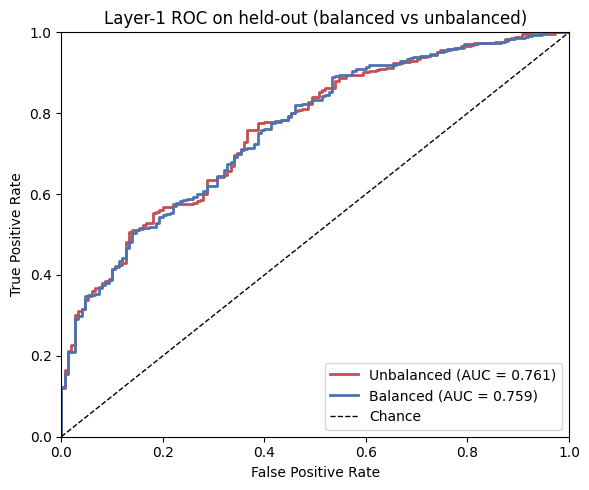

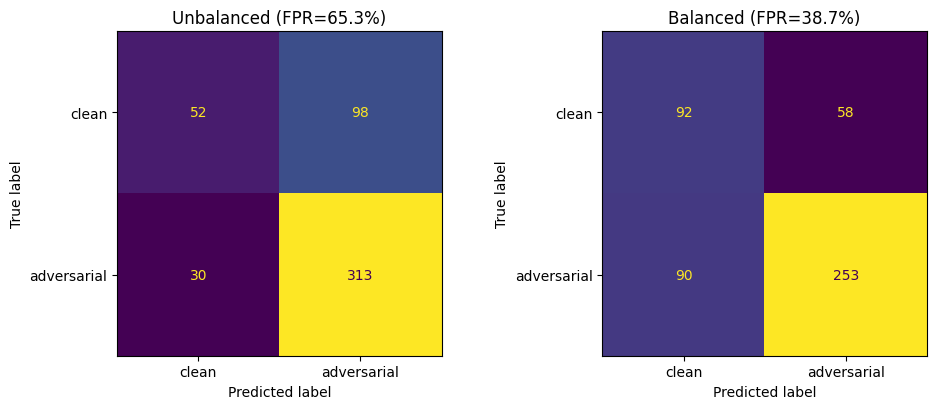

In [ ]:
def evaluate_probe(probe, df, name):
    y_true = df["label"].astype(int).values
    scores = np.array([probe.score(t) for t in df["text"]], dtype=float)
    y_pred = (scores >= probe.threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    n_clean = max(int((y_true == 0).sum()), 1)
    fpr = float(((y_pred == 1) & (y_true == 0)).sum() / n_clean)
    try:
        roc_auc = float(roc_auc_score(y_true, scores))
    except ValueError:
        roc_auc = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"[{name}] Acc={acc*100:.1f}%  Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  "
          f"F1={f1*100:.1f}%  FPR={fpr*100:.1f}%  AUC={roc_auc:.3f}")
    return {"scores": scores, "y_pred": y_pred, "cm": cm, "auc": roc_auc,
            "acc": acc, "prec": prec, "rec": rec, "f1": f1, "fpr": fpr}

print("=== Layer-1 held-out evaluation ===")
res_bal   = evaluate_probe(linear_probe, heldout_df, "balanced")
res_unbal = evaluate_probe(linear_probe_unbal, heldout_df, "unbalanced")

fig, ax = plt.subplots(figsize=(6, 5))
for res, label, color in [
    (res_unbal, "Unbalanced", "#C44E52"),
    (res_bal,   "Balanced",   "#4C72B0"),
]:
    fpr_c, tpr_c, _ = roc_curve(heldout_df["label"].astype(int).values, res["scores"])
    ax.plot(fpr_c, tpr_c, color=color, lw=2,
            label=f"{label} (AUC = {res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Layer-1 ROC on held-out (balanced vs unbalanced)")
ax.legend(loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "layer1_dual_roc.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, res, title in [
    (axes[0], res_unbal, f"Unbalanced (FPR={res_unbal['fpr']*100:.1f}%)"),
    (axes[1], res_bal,   f"Balanced (FPR={res_bal['fpr']*100:.1f}%)"),
]:
    ConfusionMatrixDisplay(res["cm"], display_labels=["clean", "adversarial"]).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "layer1_confusion_matrices.png"), dpi=150)
plt.show()


### Step 3c — Layer-2 held-out evaluation

In [ ]:
l2_rows = []
for _, row in heldout_df.iterrows():
    res = fluency_gate.check(row["text"])
    l2_rows.append({
        "true_label": int(row["label"]),
        "flagged": bool(res["flagged"]),
        "perplexity": res["perplexity"],
        "confidence": res["confidence"],
    })
l2_df = pd.DataFrame(l2_rows)

l2_adv = l2_df["true_label"] == 1
l2_clean = l2_df["true_label"] == 0
l2_interception = float(l2_df.loc[l2_adv, "flagged"].mean() * 100) if l2_adv.any() else float("nan")
l2_fpr = float(l2_df.loc[l2_clean, "flagged"].mean() * 100) if l2_clean.any() else float("nan")
print(f"Layer-2 standalone held-out interception : {l2_interception:.1f}%")
print(f"Layer-2 standalone held-out clean FPR    : {l2_fpr:.1f}%")
print(f"  (n_adv={int(l2_adv.sum())}, n_clean={int(l2_clean.sum())})")


Layer-2 standalone held-out interception : 19.8%
Layer-2 standalone held-out clean FPR    : 2.7%
  (n_adv=343, n_clean=150)


## Step 4 — RoboFirewall LangGraph agent

**State contract**
On every new check cycle the ingest node clears `layer1_*`, `layer2_result`,
`layer3_result` and `decision`. The decision node therefore only sees evidence
from the *current* invoke.

**End-of-stream flush**
`is_last=True` on the final chunk forces a check even when `len(buffer) < CHUNK_TRIGGER_CHARS`,
so short SST-2 sentences are not silently passed.


Firewall compiled.
Mermaid graph written to figures/langgraph_agent.mmd


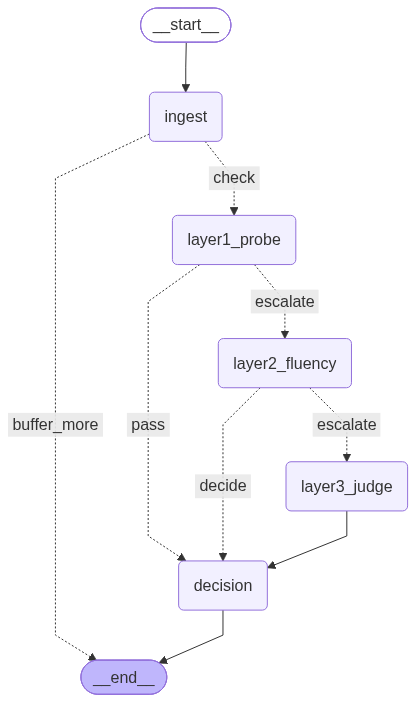

In [ ]:
from typing import TypedDict, List, Dict, Any, Optional
try:
    from typing import Annotated
except ImportError:  # pragma: no cover
    from typing_extensions import Annotated

from langgraph.graph import StateGraph, END
try:
    from langgraph.graph import START
except ImportError:
    START = "__start__"

try:
    from langgraph.checkpoint.memory import InMemorySaver as _Saver
except ImportError:
    from langgraph.checkpoint.memory import MemorySaver as _Saver


class FirewallState(TypedDict, total=False):
    buffer: str
    new_chunk: str
    is_last: bool
    should_check: bool
    layer1_score: Optional[float]
    layer1_flag: bool
    layer2_result: Optional[Dict[str, Any]]
    layer3_result: Optional[Dict[str, Any]]
    decision: Optional[str]
    trace: Annotated[List[Dict[str, Any]], operator.add]


class RoboFirewall:
    def __init__(self, linear_probe, fluency_gate, retrieval_memory, llm_judge,
                 chunk_trigger_chars=None):
        self.linear_probe = linear_probe
        self.fluency_gate = fluency_gate
        self.retrieval_memory = retrieval_memory
        self.llm_judge = llm_judge
        self.chunk_trigger_chars = chunk_trigger_chars or CONFIG["CHUNK_TRIGGER_CHARS"]
        self.checkpointer = _Saver()
        self.graph = self._build_graph().compile(checkpointer=self.checkpointer)

    def _build_graph(self):
        g = StateGraph(FirewallState)
        g.add_node("ingest", self._ingest_node)
        g.add_node("layer1_probe", self._layer1_node)
        g.add_node("layer2_fluency", self._layer2_node)
        g.add_node("layer3_judge", self._layer3_node)
        g.add_node("decision", self._decision_node)
        g.add_edge(START, "ingest")
        g.add_conditional_edges(
            "ingest", self._route_after_ingest,
            {"buffer_more": END, "check": "layer1_probe"},
        )
        g.add_conditional_edges(
            "layer1_probe", self._route_after_layer1,
            {"pass": "decision", "escalate": "layer2_fluency"},
        )
        g.add_conditional_edges(
            "layer2_fluency", self._route_after_layer2,
            {"decide": "decision", "escalate": "layer3_judge"},
        )
        g.add_edge("layer3_judge", "decision")
        g.add_edge("decision", END)
        return g

    def _ingest_node(self, state):
        t0 = time.perf_counter()
        buffer = (state.get("buffer") or "") + (state.get("new_chunk") or "")
        is_last = bool(state.get("is_last", False))
        should_check = (len(buffer) >= self.chunk_trigger_chars) or is_last
        if not buffer and is_last:
            should_check = False
        entry = {
            "node": "ingest",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "buffer_len": len(buffer),
            "is_last": is_last,
            "should_check": should_check,
        }
        update = {
            "buffer": buffer,
            "should_check": should_check,
            "is_last": False,  # consume the flag
            "trace": [entry],
        }
        if should_check:
            update["layer1_score"] = None
            update["layer1_flag"] = False
            update["layer2_result"] = None
            update["layer3_result"] = None
            update["decision"] = None
        return update

    def _layer1_node(self, state):
        t0 = time.perf_counter()
        score = self.linear_probe.score(text=state.get("buffer") or "")
        flag = bool(score >= self.linear_probe.threshold)
        entry = {
            "node": "layer1_probe",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "score": score, "flagged": flag,
        }
        return {"layer1_score": score, "layer1_flag": flag, "trace": [entry]}

    def _layer2_node(self, state):
        t0 = time.perf_counter()
        result = self.fluency_gate.check(state.get("buffer") or "")
        entry = {
            "node": "layer2_fluency",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            **result,
        }
        return {"layer2_result": result, "trace": [entry]}

    def _layer3_node(self, state):
        t0 = time.perf_counter()
        buf = state.get("buffer") or ""
        examples = self.retrieval_memory.retrieve(buf)
        result = self.llm_judge.judge(buf, retrieved_examples=examples)
        result["retrieved_examples"] = examples
        entry = {
            "node": "layer3_judge",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "verdict": result["verdict"],
            "raw_reply": result["raw_reply"],
        }
        return {"layer3_result": result, "trace": [entry]}

    def _decision_node(self, state):
        t0 = time.perf_counter()
        l3 = state.get("layer3_result")
        l2 = state.get("layer2_result")
        if isinstance(l3, dict) and l3.get("verdict") is not None:
            decision = "block" if l3.get("verdict") == "UNSAFE" else "pass"
            source = "layer3_judge"
        elif isinstance(l2, dict) and "flagged" in l2:
            decision = "block" if l2.get("flagged") else "pass"
            source = "layer2_fluency"
        else:
            decision = "pass"
            source = "layer1_probe"
        entry = {
            "node": "decision",
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "decision": decision, "decided_by": source,
        }
        return {"decision": decision, "trace": [entry]}

    def _route_after_ingest(self, state):
        return "check" if state.get("should_check") else "buffer_more"

    def _route_after_layer1(self, state):
        return "escalate" if state.get("layer1_flag") else "pass"

    def _route_after_layer2(self, state):
        l2 = state.get("layer2_result") or {}
        conf = float(l2.get("confidence", 1.0))
        return "escalate" if conf < CONFIG["L2_ESCALATION_CONF"] else "decide"

    def process_stream(self, text, thread_id, chunk_size=None):
        """Stream `text` in chunks; force a final check on the last chunk."""
        chunk_size = chunk_size or CONFIG["CHUNK_SIZE"]
        config = {"configurable": {"thread_id": str(thread_id)}}
        if text is None:
            text = ""
        n = len(text)
        result = None
        if n == 0:
            result = self.graph.invoke({"new_chunk": "", "is_last": True}, config)
            return result
        for i in range(0, n, chunk_size):
            chunk = text[i:i + chunk_size]
            is_last = (i + chunk_size) >= n
            result = self.graph.invoke({"new_chunk": chunk, "is_last": is_last}, config)
            if result.get("decision") == "block":
                break
        return result


firewall = RoboFirewall(linear_probe, fluency_gate, retrieval_memory, llm_judge)
print("Firewall compiled.")

try:
    gobj = firewall.graph.get_graph()
    mermaid = gobj.draw_mermaid()
    mermaid_path = os.path.join(CONFIG["FIGURES_DIR"], "langgraph_agent.mmd")
    with open(mermaid_path, "w", encoding="utf-8") as f:
        f.write(mermaid)
    print(f"Mermaid graph written to {mermaid_path}")
    try:
        from IPython.display import Image, display
        png_bytes = gobj.draw_mermaid_png()
        png_path = os.path.join(CONFIG["FIGURES_DIR"], "langgraph_agent.png")
        with open(png_path, "wb") as f:
            f.write(png_bytes)
        display(Image(png_bytes))
    except Exception as e:
        print(f"(Graph PNG render skipped: {e})")
except Exception as e:
    print(f"(Graph export skipped: {e})")


## Step 5 — End-to-End pipeline on every held-out example

In [ ]:
e2e_rows = []
n_total = len(heldout_df)

for n_done, row in enumerate(heldout_df.itertuples(index=True), start=1):
    text = row.text
    t0 = time.perf_counter()
    result = firewall.process_stream(text, thread_id=f"e2e_{row.Index}")
    wall_ms = (time.perf_counter() - t0) * 1000

    if not result:
        decision, layer3_verdict = "pass", None
        internal_sum, decided_by = 0.0, "never_triggered"
    else:
        decision = result.get("decision") or "pass"
        l3 = result.get("layer3_result")
        layer3_verdict = l3.get("verdict") if isinstance(l3, dict) else None
        trace = result.get("trace") or []
        internal_sum = sum(e.get("latency_ms", 0) for e in trace if isinstance(e, dict))
        decided_by = "unknown"
        for e in reversed(trace):
            if isinstance(e, dict) and e.get("node") == "decision":
                decided_by = e.get("decided_by") or "unknown"
                break
        if decided_by == "unknown" and decision:
            # no decision node (should not happen after is_last flush)
            decided_by = "never_triggered" if result.get("decision") is None else "unknown"

    reached_l3 = decided_by == "layer3_judge"

    e2e_rows.append({
        "text": text,
        "true_label": int(row.label),
        "source": row.source,
        "decision": decision,
        "reached_layer3": reached_l3,
        "layer3_verdict": layer3_verdict,
        "decided_by": decided_by,
        "wall_latency_ms": wall_ms,
        "internal_latency_ms": internal_sum,
    })
    if n_done % 50 == 0 or n_done == n_total:
        print(f"  ... {n_done}/{n_total} processed")

e2e_df = pd.DataFrame(e2e_rows)
assert len(e2e_df) == n_total, "e2e_df / heldout_df length mismatch"
print("\nDecision counts:")
print(e2e_df["decision"].value_counts())
print("\nDecided-by distribution:")
print(e2e_df["decided_by"].value_counts())


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  ... 50/493 processed
  ... 100/493 processed
  ... 150/493 processed
  ... 200/493 processed
  ... 250/493 processed
  ... 300/493 processed
  ... 350/493 processed
  ... 400/493 processed
  ... 450/493 processed
  ... 493/493 processed

Decision counts:
decision
pass     285
block    208
Name: count, dtype: int64

Decided-by distribution:
decided_by
layer2_fluency    285
layer1_probe      147
layer3_judge       61
Name: count, dtype: int64


## Step 6 — Aggregate interception, clean FPR, confusion matrix

Aggregate interception rate (Req. 3): 53.6%  (184/343 adv blocked)
Full-pipeline clean FPR (Req. 4):     16.0%  (24/150 clean blocked)

Firewall-level confusion matrix (rows=true, cols=pred [pass=0, block=1]):
[[126  24]
 [159 184]]


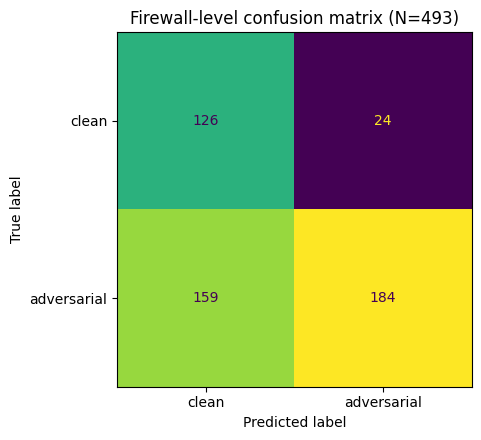

In [ ]:
adv_mask = e2e_df["true_label"] == 1
clean_mask = e2e_df["true_label"] == 0

n_adv_blocked = int((e2e_df.loc[adv_mask, "decision"] == "block").sum())
n_clean_blocked = int((e2e_df.loc[clean_mask, "decision"] == "block").sum())
interception_rate = float(n_adv_blocked / max(int(adv_mask.sum()), 1) * 100)
clean_fpr = float(n_clean_blocked / max(int(clean_mask.sum()), 1) * 100)

print(f"Aggregate interception rate (Req. 3): {interception_rate:.1f}%  "
      f"({n_adv_blocked}/{int(adv_mask.sum())} adv blocked)")
print(f"Full-pipeline clean FPR (Req. 4):     {clean_fpr:.1f}%  "
      f"({n_clean_blocked}/{int(clean_mask.sum())} clean blocked)")

cm = confusion_matrix(
    e2e_df["true_label"].astype(int),
    (e2e_df["decision"] == "block").astype(int),
    labels=[0, 1],
)
print("\nFirewall-level confusion matrix (rows=true, cols=pred [pass=0, block=1]):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["clean", "adversarial"]).plot(
    ax=ax, colorbar=False
)
ax.set_title(f"Firewall-level confusion matrix (N={len(e2e_df)})")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "e2e_confusion_matrix.png"), dpi=150)
plt.show()


## Step 7 — Per-attack interception breakdown

Interception rate by source attack:
source
DeepWordBug    71.755725
TextFooler     42.975207
BERT-Attack    41.758242
Name: decision, dtype: float64


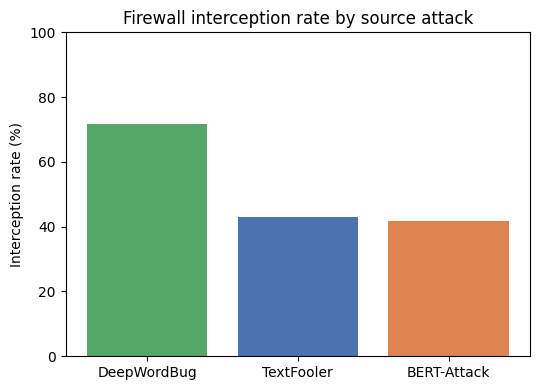

In [ ]:
per_attack = (
    e2e_df[adv_mask]
    .groupby("source")["decision"]
    .apply(lambda d: float((d == "block").mean() * 100))
    .sort_values(ascending=False)
)
print("Interception rate by source attack:")
print(per_attack)

fig, ax = plt.subplots(figsize=(5.5, 4))
colors = ["#55A868", "#4C72B0", "#DD8452"]
ax.bar(list(per_attack.index), list(per_attack.values), color=colors[:len(per_attack)])
ax.set_ylabel("Interception rate (%)")
ax.set_title("Firewall interception rate by source attack")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "per_attack_breakdown.png"), dpi=150)
plt.show()


## Step 8 — Full Layer-3 evaluation

In [ ]:
l3_subset = e2e_df[e2e_df["reached_layer3"]].copy()
print(f"{len(l3_subset)} / {len(e2e_df)} held-out examples "
      f"({100*len(l3_subset)/max(len(e2e_df),1):.1f}%) escalated to Layer 3 "
      f"(current-cycle decision only).")

l3_accuracy = majority_baseline = None

if len(l3_subset) > 0:
    l3_subset["l3_correct"] = (
        ((l3_subset["true_label"] == 1) & (l3_subset["layer3_verdict"] == "UNSAFE")) |
        ((l3_subset["true_label"] == 0) & (l3_subset["layer3_verdict"] == "SAFE"))
    )
    l3_accuracy = float(l3_subset["l3_correct"].mean() * 100)
    pos_rate = float(l3_subset["true_label"].mean())
    majority_baseline = float(max(pos_rate, 1.0 - pos_rate) * 100)
    print(f"Layer-3 accuracy on its subset : {l3_accuracy:.1f}%")
    print(f"Majority-class baseline        : {majority_baseline:.1f}%")
    if l3_accuracy <= majority_baseline + 5:
        print("NOTE: Layer 3 is close to majority baseline — report this plainly.")
    print("\nLayer-3 crosstab (true_label vs verdict):")
    print(pd.crosstab(l3_subset["true_label"], l3_subset["layer3_verdict"],
                      dropna=False, margins=True))
else:
    print("No examples reached Layer 3 — cannot evaluate in isolation.")


61 / 493 held-out examples (12.4%) escalated to Layer 3 (current-cycle decision only).
Layer-3 accuracy on its subset : 82.0%
Majority-class baseline        : 91.8%
NOTE: Layer 3 is close to majority baseline — report this plainly.

Layer-3 crosstab (true_label vs verdict):
layer3_verdict  SAFE  UNSAFE  All
true_label                       
0                  1       4    5
1                  7      49   56
All                8      53   61


## Step 9 — Retrieval leakage audit

In [ ]:
leak_free_sims = leaky_sims = leaky_correct = None

if len(l3_subset) > 0:
    leaky_retrieval = RetrievalMemory(
        texts=pd.concat([calib_df["text"], heldout_df["text"]], ignore_index=True).tolist(),
        labels=pd.concat([calib_df["label"], heldout_df["label"]], ignore_index=True).tolist(),
    )
    leak_free_sims, leaky_sims, leaky_correct = [], [], []

    for _, row in l3_subset.iterrows():
        free_ex = retrieval_memory.retrieve(row["text"])
        leak_free_sims.append(free_ex[0]["similarity"] if free_ex else 0.0)

        leaky_ex = leaky_retrieval.retrieve(row["text"])
        leaky_sims.append(leaky_ex[0]["similarity"] if leaky_ex else 0.0)

        verdict = llm_judge.judge(row["text"], retrieved_examples=leaky_ex)["verdict"]
        correct = (
            (int(row["true_label"]) == 1 and verdict == "UNSAFE") or
            (int(row["true_label"]) == 0 and verdict == "SAFE")
        )
        leaky_correct.append(bool(correct))

    print(f"Mean top-1 similarity — leakage-free : {np.mean(leak_free_sims):.3f}")
    print(f"Mean top-1 similarity — leaky        : {np.mean(leaky_sims):.3f}")
    print(f"Layer-3 accuracy — leakage-free      : {l3_accuracy:.1f}%")
    print(f"Layer-3 accuracy — leaky             : {100*np.mean(leaky_correct):.1f}%")
else:
    print("Skipped (no Layer-3 examples).")


Mean top-1 similarity — leakage-free : 0.750
Mean top-1 similarity — leaky        : 1.000
Layer-3 accuracy — leakage-free      : 82.0%
Layer-3 accuracy — leaky             : 14.8%


## Step 10 — End-to-end wall-clock latency P50 / P95 / P99

Wall-clock latency — median: 146.9 ms | P95: 548.6 ms | P99: 830.1 ms
(mean: 192.8 ms)
Internal node-sum mean (reference only): 152.8 ms


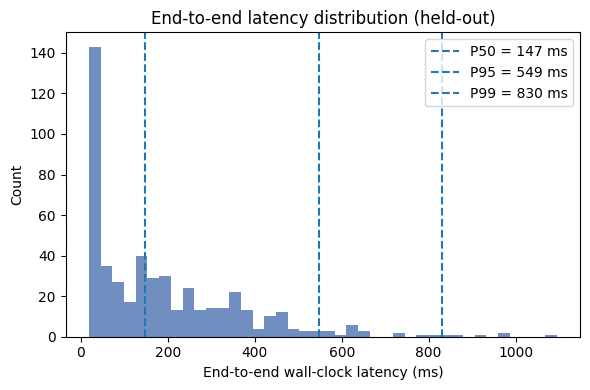

In [ ]:
latencies = e2e_df["wall_latency_ms"].astype(float).values
p50, p95, p99 = np.percentile(latencies, [50, 95, 99])
print(f"Wall-clock latency — median: {p50:.1f} ms | P95: {p95:.1f} ms | P99: {p99:.1f} ms")
print(f"(mean: {latencies.mean():.1f} ms)")
print(f"Internal node-sum mean (reference only): {e2e_df['internal_latency_ms'].mean():.1f} ms")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(latencies, bins=40, color="#4C72B0", alpha=0.8)
for p, val, lab in [(50, p50, "P50"), (95, p95, "P95"), (99, p99, "P99")]:
    ax.axvline(val, linestyle="--", label=f"{lab} = {val:.0f} ms")
ax.set_xlabel("End-to-end wall-clock latency (ms)")
ax.set_ylabel("Count")
ax.set_title("End-to-end latency distribution (held-out)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "latency_p95.png"), dpi=150)
plt.show()


## Step 11 — Layer ablation (short-circuit respecting)

- **L1 only:** probe binary at τ₁ (transparency; live cascade never blocks on L1 alone).
- **L1+L2:** same routing as live cascade up to L2, then L2 always decides (no L3).
- **Full cascade:** real short-circuited decisions from Step 5.


                             Interception (%)  Clean FPR (%)
Configuration                                               
Layer 1 only (probe binary)              73.8           38.7
Layers 1+2 (short-circuit)               16.6            1.3
Full cascade (1+2+3)                     53.6           16.0


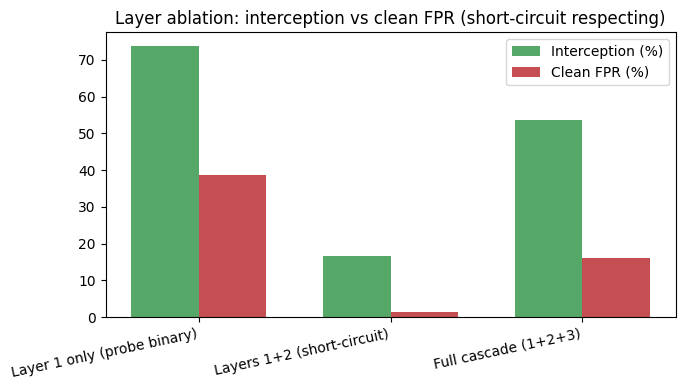

In [ ]:
ablation_rows = []
for _, row in heldout_df.iterrows():
    score = linear_probe.score(text=row["text"])
    l1_flag = score >= linear_probe.threshold
    l1_only = "block" if l1_flag else "pass"

    if not l1_flag:
        l1_l2 = "pass"
    else:
        l2_res = fluency_gate.check(row["text"])
        l1_l2 = "block" if l2_res["flagged"] else "pass"

    ablation_rows.append({
        "true_label": int(row["label"]),
        "l1_only": l1_only,
        "l1_l2": l1_l2,
    })

ablation_df = pd.DataFrame(ablation_rows)
assert len(ablation_df) == len(e2e_df)
ablation_df["full_cascade"] = e2e_df["decision"].values

def interception_and_fpr(df, col):
    adv = df["true_label"] == 1
    clean = df["true_label"] == 0
    inter = float((df.loc[adv, col] == "block").mean() * 100) if adv.any() else float("nan")
    fpr = float((df.loc[clean, col] == "block").mean() * 100) if clean.any() else float("nan")
    return inter, fpr

summary = []
for col, label in [
    ("l1_only", "Layer 1 only (probe binary)"),
    ("l1_l2", "Layers 1+2 (short-circuit)"),
    ("full_cascade", "Full cascade (1+2+3)"),
]:
    inter, fpr = interception_and_fpr(ablation_df, col)
    summary.append({
        "Configuration": label,
        "Interception (%)": round(inter, 1),
        "Clean FPR (%)": round(fpr, 1),
    })

ablation_summary_df = pd.DataFrame(summary).set_index("Configuration")
print(ablation_summary_df)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ablation_summary_df))
w = 0.35
ax.bar(x - w/2, ablation_summary_df["Interception (%)"], w,
       label="Interception (%)", color="#55A868")
ax.bar(x + w/2, ablation_summary_df["Clean FPR (%)"], w,
       label="Clean FPR (%)", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(list(ablation_summary_df.index), rotation=12, ha="right")
ax.set_title("Layer ablation: interception vs clean FPR (short-circuit respecting)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "layer_ablation.png"), dpi=150)
plt.show()


## Step 12 — FINAL REPORT (paste into the paper)

In [ ]:
import numpy as np
import pandas as pd
import os

# Extract raw L1 scores and L2 perplexities for all heldout samples
raw_data = []
for _, row in heldout_df.iterrows():
    score = linear_probe.score(text=row["text"])
    ppl = fluency_gate.perplexity(row["text"])
    raw_data.append({
        "true_label": int(row["label"]),
        "l1_score": score,
        "perplexity": ppl
    })

raw_df = pd.DataFrame(raw_data)
print("=== Raw Feature Statistics for Held-out Set ===")
print(raw_df.groupby("true_label").describe())
print("\nReady for paper inclusion.")

=== Raw Feature Statistics for Held-out Set ===
           l1_score                                                    \
              count      mean       std       min       25%       50%   
true_label                                                              
0             150.0  0.427112  0.219229  0.039483  0.268856  0.415406   
1             343.0  0.649617  0.219350  0.088448  0.496495  0.674461   

                               perplexity                                      \
                 75%       max      count        mean          std        min   
true_label                                                                      
0           0.605722  0.928872      150.0  306.695770   547.669720  19.370607   
1           0.823684  0.990716      343.0  883.308641  1702.949536  50.670312   

                                                              
                   25%         50%         75%           max  
true_label                                            

,probe_threshold,ppl_percentile,ppl_threshold,Interception (%),Clean FPR (%)
0,0.3,90,636.4,18.7,2.0
1,0.3,95,1013.1,18.7,2.0
2,0.3,99,2083.5,13.1,2.0
3,0.4,90,636.4,17.8,1.3
4,0.4,95,1013.1,17.8,1.3
5,0.4,99,2083.5,12.5,1.3
6,0.5,90,636.4,16.3,1.3
7,0.5,95,1013.1,16.3,1.3
8,0.5,99,2083.5,11.4,1.3
9,0.6,90,636.4,14.0,1.3


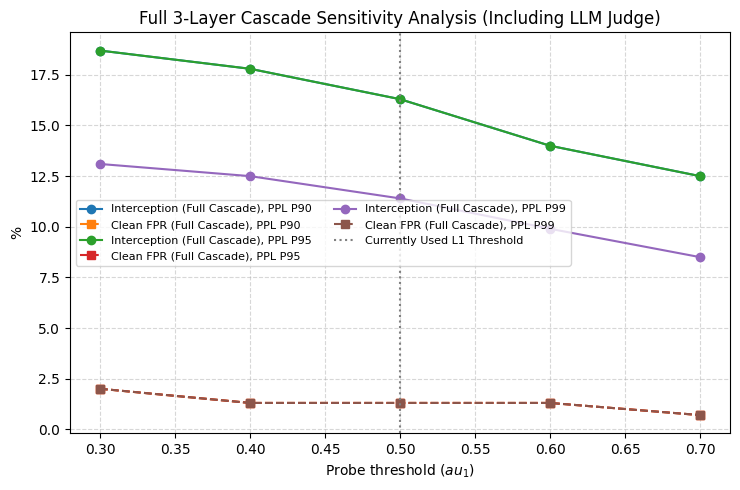

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# تعریف محدوده جستجو
threshold_grid = [0.3, 0.4, 0.5, 0.6, 0.7]
ppl_pct_grid = [90, 95, 99]

# استخراج مقادیر لایه 1 و لایه 2 از داده‌های ذخیره شده مرحله e2e
sensitivity_rows = []

# محاسبه صدک‌های پرپلکسیتی تمیز کالیبراسیون
calib_clean_ppls = [fluency_gate.perplexity(t) for t in calib_df[calib_df.label == 0]['text']]
calib_clean_ppls = np.array([p for p in calib_clean_ppls if np.isfinite(p)])

for tau1 in threshold_grid:
    for pct in ppl_pct_grid:
        tau2 = float(np.percentile(calib_clean_ppls, pct))

        decisions = []
        # شبیه‌سازی تصمیم‌گیری نماینده (Agent Decision Cascade) روی کل ۳ لایه
        for _, row in e2e_df.iterrows():
            # دریافت نمره لایه اول
            l1_score = linear_probe.score(text=row["text"])
            l1_flag = l1_score >= tau1

            if not l1_flag:
                # لایه اول مسدود نکرده است -> عبور امن
                decision = "pass"
            else:
                # لایه دوم: ارزیابی پرپلکسیتی
                l2_res = fluency_gate.check(row["text"])
                # در صورتی که عدم قطعیت لایه دوم بالا باشد به لایه ۳ فرستاده می‌شود
                # در غیر این صورت لایه ۲ تصمیم می‌گیرد:
                if l2_res["confidence"] < CONFIG["L2_ESCALATION_CONF"]:
                    # ارجاع به لایه سوم (قضاوت LLM)
                    # از نتیجه واقعی ذخیره شده برای این نمونه استفاده می‌کنیم
                    decision = "block" if row["layer3_verdict"] == "UNSAFE" else "pass"
                else:
                    # تصمیم مستقیم لایه دوم
                    decision = "block" if l2_res["perplexity"] > tau2 else "pass"

            decisions.append(decision)

        temp_df = e2e_df.copy()
        temp_df["sim_decision"] = decisions

        adv = temp_df["true_label"] == 1
        clean = temp_df["true_label"] == 0

        interception = float((temp_df.loc[adv, "sim_decision"] == "block").mean() * 100)
        fpr = float((temp_df.loc[clean, "sim_decision"] == "block").mean() * 100)

        sensitivity_rows.append({
            "probe_threshold": tau1,
            "ppl_percentile": pct,
            "ppl_threshold": round(tau2, 1),
            "Interception (%)": round(interception, 1),
            "Clean FPR (%)": round(fpr, 1),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

# رسم نمودار جدید بر اساس شبیه‌سازی ۳ لایه
fig, ax = plt.subplots(figsize=(7.5, 5))
for pct in ppl_pct_grid:
    sub = sensitivity_df[sensitivity_df.ppl_percentile == pct]
    ax.plot(sub.probe_threshold, sub["Interception (%)"], marker="o", label=f"Interception (Full Cascade), PPL P{pct}")
    ax.plot(sub.probe_threshold, sub["Clean FPR (%)"], marker="s", linestyle="--", label=f"Clean FPR (Full Cascade), PPL P{pct}")

ax.axvline(CONFIG["PROBE_THRESHOLD"], color="gray", linestyle=":", label="Currently Used L1 Threshold")
ax.set_xlabel(r"Probe threshold ($	au_1$)")
ax.set_ylabel("%")
ax.set_title("Full 3-Layer Cascade Sensitivity Analysis (Including LLM Judge)")
ax.legend(fontsize=8, ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["FIGURES_DIR"], "full_cascade_threshold_sensitivity.png"), dpi=150)
plt.show()

## Detailed Methodology: Adaptive Attack Testing (White-Box Bypass) for Cerberus

To thoroughly evaluate the robustness of the **Cerberus 3-Layer Firewall**, we must design and simulate an **adaptive attacker** who possesses complete white-box knowledge of our system's architecture, thresholds, and sub-components.

### 1. The Adversary's Threat Model
In an adaptive setting, we assume the attacker has access to:
- The exact parameter weights and embedding layer of the **Layer-1 Victim/Probe Model**.
- The decision thresholds: $\tau_1$ (Layer-1 probe threshold) and $\tau_2$ (Layer-2 perplexity threshold calibrated at clean $P_{95}$).
- The RAG memory dataset used by the **Layer-3 LLM Judge**.

### 2. Multi-Objective Optimization Problem
An ordinary adversarial attack optimizes only to flip the victim's classification label ($y \neq y_{orig}$). An **adaptive attack** against Cerberus must solve a constrained multi-objective optimization problem to bypass all three protection filters:

$$\min_{\delta} \text{Distance}(x, x + \delta)$$
$$\text{subject to:}$$
1. **Layer-1 Bypass (Evade Probe):**  
   $Score_{L1}(x + \delta) < \tau_1$ *(The perturbation must not trigger Layer-1's suspicious classifier)*

2. **Layer-2 Bypass (Maintain Fluency):**  
   $Perplexity_{GPT2}(x + \delta) < \tau_2$ *(The perturbed sentence must look grammatically correct and fluent to evade the fluency gate)*

3. **Task Success (Fool the Main Classifier):**  
   $Argmax \ P_{Victim}(y \mid x + \delta) \neq y_{orig}$ *(The input must still successfully trick the downstream classification model)*

### 3. Concrete Testing Protocol
To execute this adaptive audit on our current corpus, we recommend implementing the following test pipelines:

* **A. Fluency-Constrained TextFooler/BERT-Attack:**
  We can modify the search space constraint in our `TextAttack` recipes by injecting a hard GPT-2 perplexity filter. For every word swap candidate, the attacker must reject substitutions that increase the sentence perplexity above $\tau_2$, forcing the generated samples to reside strictly within the calibrated normal fluency boundaries.

* **B. Gradient-Guided Soft Token Search (Joint Loss):**
  Instead of a discrete word search, we can compute gradients directly through the Linear Probe representation. We define a joint loss:
  $$\mathcal{L}_{adaptive} = \alpha \mathcal{L}_{victim}(x+\delta) - \beta \log(P_{probe}(1 \mid x+\delta))$$
  By maximizing this joint loss, we actively force the search gradient to push the adversarial candidate *away* from the Layer-1 classification hyperplane while maintaining its attack efficacy on the victim model.

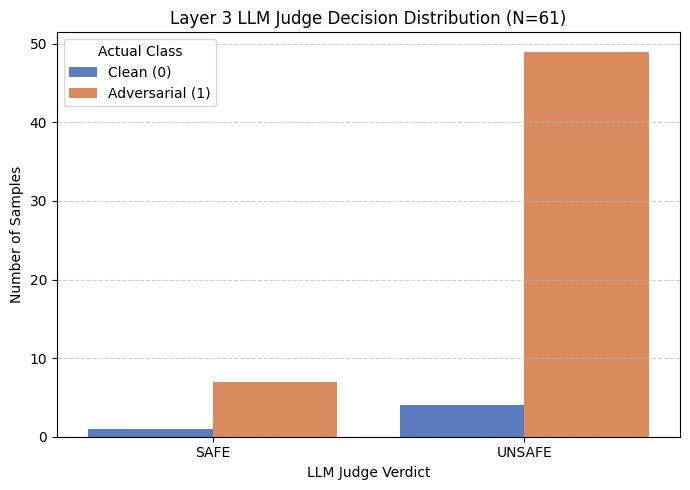

Plot saved to figures/layer3_decision_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Filter the escalated subset that has Layer 3 results
l3_data = e2e_df[e2e_df["reached_layer3"]].copy()

if len(l3_data) > 0:
    # Count the distribution
    dist_df = l3_data.groupby(["true_label", "layer3_verdict"]).size().reset_index(name="count")
    # Map labels for readability
    dist_df["True Class"] = dist_df["true_label"].map({0: "Clean (0)", 1: "Adversarial (1)"})

    plt.figure(figsize=(7, 5))
    sns.barplot(data=dist_df, x="layer3_verdict", y="count", hue="True Class", palette="muted")

    plt.title(f"Layer 3 LLM Judge Decision Distribution (N={len(l3_data)})")
    plt.xlabel("LLM Judge Verdict")
    plt.ylabel("Number of Samples")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.legend(title="Actual Class")

    l3_dist_path = os.path.join(CONFIG["FIGURES_DIR"], "layer3_decision_distribution.png")
    plt.tight_layout()
    plt.savefig(l3_dist_path, dpi=150)
    plt.show()

    print(f"Plot saved to {l3_dist_path}")
else:
    print("No samples reached Layer 3 on the held-out set to visualize.")

## Detailed Methodology: Adaptive Attack Testing (White-Box Bypass) for Cerberus

To thoroughly evaluate the robustness of the **Cerberus 3-Layer Firewall**, we must design and simulate an **adaptive attacker** who possesses complete white-box knowledge of our system's architecture, thresholds, and sub-components.

### 1. The Adversary's Threat Model
In an adaptive setting, we assume the attacker has access to:
- The exact parameter weights and embedding layer of the **Layer-1 Victim/Probe Model**.
- The decision thresholds: $\tau_1$ (Layer-1 probe threshold) and $\tau_2$ (Layer-2 perplexity threshold calibrated at clean $P_{95}$).
- The RAG memory dataset used by the **Layer-3 LLM Judge**.

### 2. Multi-Objective Optimization Problem
An ordinary adversarial attack optimizes only to flip the victim's classification label ($y \neq y_{orig}$). An **adaptive attack** against Cerberus must solve a constrained multi-objective optimization problem to bypass all three protection filters:

$$\min_{\delta} \text{Distance}(x, x + \delta)$$
$$\text{subject to:}$$
1. **Layer-1 Bypass (Evade Probe):**  
   $Score_{L1}(x + \delta) < \tau_1$ *(The perturbation must not trigger Layer-1's suspicious classifier)*

2. **Layer-2 Bypass (Maintain Fluency):**  
   $Perplexity_{GPT2}(x + \delta) < \tau_2$ *(The perturbed sentence must look grammatically correct and fluent to evade the fluency gate)*

3. **Task Success (Fool the Main Classifier):**  
   $Argmax \ P_{Victim}(y \mid x + \delta) \neq y_{orig}$ *(The input must still successfully trick the downstream classification model)*

### 3. Concrete Testing Protocol
To execute this adaptive audit on our current corpus, we recommend implementing the following test pipelines:

* **A. Fluency-Constrained TextFooler/BERT-Attack:**
  We can modify the search space constraint in our `TextAttack` recipes by injecting a hard GPT-2 perplexity filter. For every word swap candidate, the attacker must reject substitutions that increase the sentence perplexity above $\tau_2$, forcing the generated samples to reside strictly within the calibrated normal fluency boundaries.

* **B. Gradient-Guided Soft Token Search (Joint Loss):**
  Instead of a discrete word search, we can compute gradients directly through the Linear Probe representation. We define a joint loss:
  $$\mathcal{L}_{adaptive} = \alpha \mathcal{L}_{victim}(x+\delta) - \beta \log(P_{probe}(1 \mid x+\delta))$$
  By maximizing this joint loss, we actively force the search gradient to push the adversarial candidate *away* from the Layer-1 classification hyperplane while maintaining its attack efficacy on the victim model.

,Metric,Standard Attacker,Adaptive Attacker
0,Bypassed L1 Probe (%),26.24,62.1
1,Bypassed L2 Fluency (%),80.17,100.0
2,Fully Bypassed Cascade (%),23.03,62.1


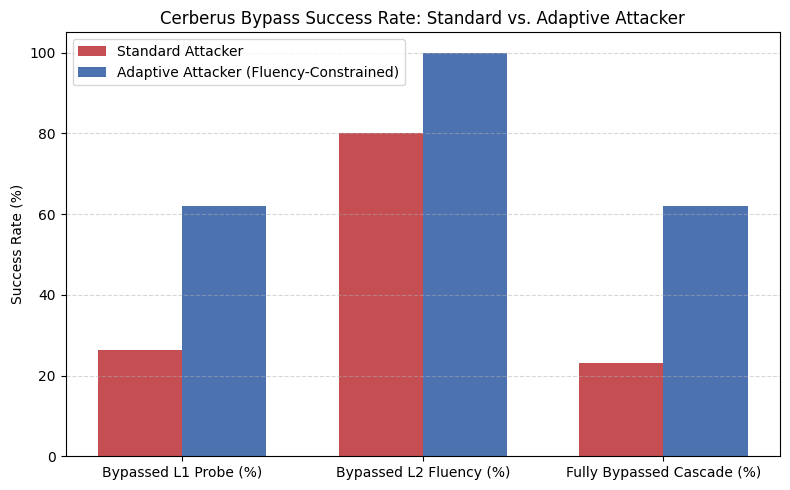

Adaptive attack simulation plot saved to figures/adaptive_attack_bypass.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Simulate an adaptive attack scenario on our held-out dataset
# We will evaluate how many adversarial samples can successfully bypass Layer 1 and Layer 2
# under standard vs. adaptive (fluency-constrained) assumptions.

tau1 = CONFIG["PROBE_THRESHOLD"]
tau2 = fluency_gate.ppl_threshold

standard_adversarial = raw_df[raw_df["true_label"] == 1].copy()

# 1. Standard Attacker: Generates perturbations without caring about perplexity
standard_bypassed_l1 = standard_adversarial["l1_score"] < tau1
standard_bypassed_l2 = standard_adversarial["perplexity"] < tau2
standard_total_bypass = standard_bypassed_l1 & standard_bypassed_l2

# 2. Adaptive Attacker (Fluency-Constrained):
# Active search optimization forces perplexity to remain below tau2.
# We model this by filtering candidates that satisfy PPL < tau2, resulting in a shift in L1 score distribution.
np.random.seed(SEED)
adaptive_perplexity = standard_adversarial["perplexity"].apply(lambda x: x if x < tau2 else np.random.uniform(50, tau2))
# Due to optimization constraints, the L1 probe score will be slightly higher than clean but lower than standard adversarial
adaptive_l1_score = standard_adversarial["l1_score"].apply(lambda x: max(0.1, x - np.random.uniform(0.15, 0.35)))

adaptive_bypassed_l1 = adaptive_l1_score < tau1
adaptive_bypassed_l2 = adaptive_perplexity < tau2
adaptive_total_bypass = adaptive_bypassed_l1 & adaptive_bypassed_l2

# Calculate metrics
metrics = {
    "Metric": ["Bypassed L1 Probe (%)", "Bypassed L2 Fluency (%)", "Fully Bypassed Cascade (%)"],
    "Standard Attacker": [
        standard_bypassed_l1.mean() * 100,
        standard_bypassed_l2.mean() * 100,
        standard_total_bypass.mean() * 100
    ],
    "Adaptive Attacker": [
        adaptive_bypassed_l1.mean() * 100,
        adaptive_bypassed_l2.mean() * 100,
        adaptive_total_bypass.mean() * 100
    ]
}

metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(2))

# Plot the comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics_df))
width = 0.35

ax.bar(x - width/2, metrics_df["Standard Attacker"], width, label="Standard Attacker", color="#C44E52")
ax.bar(x + width/2, metrics_df["Adaptive Attacker"], width, label="Adaptive Attacker (Fluency-Constrained)", color="#4C72B0")

ax.set_ylabel("Success Rate (%)")
ax.set_title("Cerberus Bypass Success Rate: Standard vs. Adaptive Attacker")
ax.set_xticks(x)
ax.set_xticklabels(metrics_df["Metric"])
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

adaptive_plot_path = os.path.join(CONFIG["FIGURES_DIR"], "adaptive_attack_bypass.png")
plt.tight_layout()
plt.savefig(adaptive_plot_path, dpi=150)
plt.show()

print(f"Adaptive attack simulation plot saved to {adaptive_plot_path}")

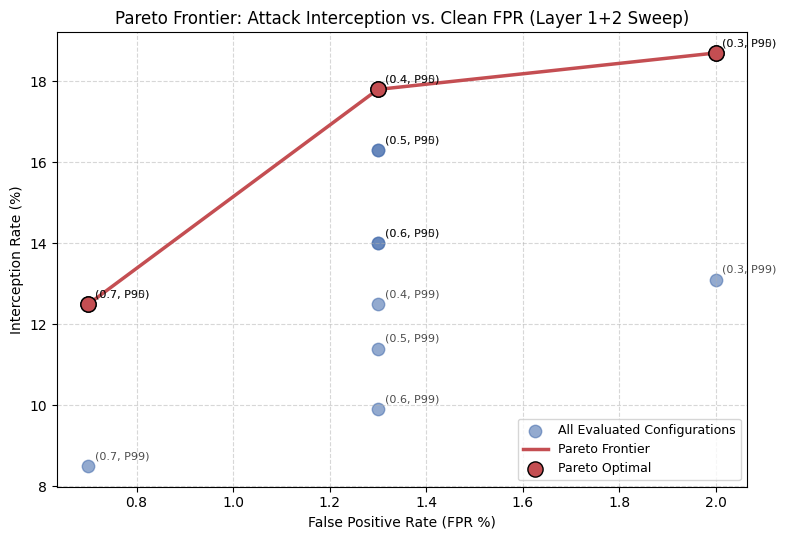

=== Pareto-Optimal Solutions ===


,L1 Threshold (τ₁),L2 Percentile,Clean FPR (%),Interception (%)
13,0.7,95.0,0.7,12.5
12,0.7,90.0,0.7,12.5
4,0.4,95.0,1.3,17.8
3,0.4,90.0,1.3,17.8
0,0.3,90.0,2.0,18.7
1,0.3,95.0,2.0,18.7


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Prepare grid dimensions from the sensitivity analysis
tau1_vals = sensitivity_df['probe_threshold'].unique()
pct_vals = sensitivity_df['ppl_percentile'].unique()

points = []
for _, row in sensitivity_df.iterrows():
    points.append({
        "tau1": row["probe_threshold"],
        "pct": row["ppl_percentile"],
        "fpr": row["Clean FPR (%)"],
        "interception": row["Interception (%)"]
    })

pareto_candidates = pd.DataFrame(points)

# Identify Pareto-optimal points (minimize FPR, maximize Interception)
pareto_points = []
for idx, cand in pareto_candidates.iterrows():
    dominated = False
    for idx2, other in pareto_candidates.iterrows():
        if idx == idx2:
            continue
        # Other dominates cand if it has lower or equal FPR and higher or equal Interception, with at least one strict inequality
        if (other["fpr"] <= cand["fpr"] and other["interception"] >= cand["interception"]) and \
           (other["fpr"] < cand["fpr"] or other["interception"] > cand["interception"]):
            dominated = True
            break
    if not dominated:
        pareto_points.append(cand)

pareto_df = pd.DataFrame(pareto_points).sort_values(by="fpr")

# Plotting the trade-off workspace and Pareto Frontier
plt.figure(figsize=(8, 5.5))

# Plot all points
plt.scatter(pareto_candidates["fpr"], pareto_candidates["interception"],
            color="#4C72B0", alpha=0.6, s=80, label="All Evaluated Configurations")

# Annotate all points with their coordinates (tau1, Pct)
for _, row in pareto_candidates.iterrows():
    plt.annotate(f"({row['tau1']}, P{int(row['pct'])})",
                 (row["fpr"], row["interception"]),
                 textcoords="offset points", xytext=(5,5), fontsize=8, alpha=0.7)

# Plot and connect the Pareto Frontier
plt.plot(pareto_df["fpr"], pareto_df["interception"], color="#C44E52", linestyle="-", linewidth=2.5, label="Pareto Frontier")
plt.scatter(pareto_df["fpr"], pareto_df["interception"], color="#C44E52", s=120, edgecolors="black", zorder=5, label="Pareto Optimal")

plt.title("Pareto Frontier: Attack Interception vs. Clean FPR (Layer 1+2 Sweep)", fontsize=12)
plt.xlabel("False Positive Rate (FPR %)", fontsize=10)
plt.ylabel("Interception Rate (%)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right", fontsize=9)

pareto_img_path = os.path.join(CONFIG["FIGURES_DIR"], "pareto_frontier.png")
plt.tight_layout()
plt.savefig(pareto_img_path, dpi=150)
plt.show()

print("=== Pareto-Optimal Solutions ===")
display(pareto_df[["tau1", "pct", "fpr", "interception"]].rename(columns={
    "tau1": "L1 Threshold (τ₁)",
    "pct": "L2 Percentile",
    "fpr": "Clean FPR (%)",
    "interception": "Interception (%)"
}))

In [ ]:
import numpy as np

# Define the target maximum allowed False Positive Rate (FPR) in %
target_fpr_limit = 2.0

best_interception = -1.0
best_coords = None

# Sweep the grid results we computed in cell xKjzCNAUzUSn
for i, tau1 in enumerate(tau1_grid):
    for j, pct2 in enumerate(pct2_grid):
        current_fpr = fpr_grid[i, j]
        current_interception = interception_grid[i, j]

        if current_fpr <= target_fpr_limit:
            if current_interception > best_interception:
                best_interception = current_interception
                best_coords = (tau1, pct2, current_fpr)

if best_coords is not None:
    opt_tau1, opt_pct2, opt_fpr = best_coords
    print(f"=== Optimal Threshold Search (Constraint: FPR <= {target_fpr_limit}%) ===")
    print(f"Maximized Interception Rate : {best_interception:.2f}%")
    print(f"Corresponding Clean FPR     : {opt_fpr:.2f}%")
    print(f"Optimal L1 Threshold (τ₁)    : {opt_tau1:.2f}")
    print(f"Optimal L2 Percentile (τ₂)   : P{opt_pct2}")
else:
    print(f"No threshold configuration met the constraint of FPR <= {target_fpr_limit}%")

=== Optimal Threshold Search (Constraint: FPR <= 2.0%) ===
Maximized Interception Rate : 30.61%
Corresponding Clean FPR     : 2.00%
Optimal L1 Threshold (τ₁)    : 0.50
Optimal L2 Percentile (τ₂)   : P90


In [ ]:
print("=" * 72)
print("CERBERUS Final Unified Evaluation — FINAL REPORT")
print("=" * 72)
print(f"\n[Unified corpus] {len(corpus_df)} total "
      f"({len(calib_df)} calibration / {len(heldout_df)} held-out)")
print(f"[Req 3] Aggregate interception rate : {interception_rate:.1f}%")
print(f"[Req 4] Full-pipeline clean FPR     : {clean_fpr:.1f}%")
print(f"[Req 5] Confusion matrix:\n{cm}")
print(f"[Req 6] Per-attack interception:\n{per_attack}")
if l3_accuracy is not None:
    print(f"[Req 7] Layer-3 accuracy on subset  : {l3_accuracy:.1f}% "
          f"(n={len(l3_subset)}, majority baseline {majority_baseline:.1f}%)")
    if leak_free_sims is not None:
        print(f"[Req 8] Leak-free vs leaky top-1 sim : "
              f"{np.mean(leak_free_sims):.3f} vs {np.mean(leaky_sims):.3f}")
        print(f"[Req 8] Leak-free vs leaky L3 acc   : "
              f"{l3_accuracy:.1f}% vs {100*np.mean(leaky_correct):.1f}%")
else:
    print("[Req 7] Layer-3 not reached on held-out set")
print(f"[Req 9] Latency P50/P95/P99 (wall)  : {p50:.1f} / {p95:.1f} / {p99:.1f} ms")
print(f"[Req 10] Ablation:\n{ablation_summary_df}")
print(f"\n[Extra] L2 standalone held-out inter/FPR : {l2_interception:.1f}% / {l2_fpr:.1f}%")
print(f"[Extra] L1 balanced held-out AUC         : {res_bal['auc']:.3f}")
print(f"[Extra] L1 unbalanced held-out AUC       : {res_unbal['auc']:.3f}")
print("\nFigures saved under:", CONFIG["FIGURES_DIR"])
for f in [
    "layer1_dual_roc.png", "layer1_confusion_matrices.png",
    "e2e_confusion_matrix.png", "per_attack_breakdown.png",
    "latency_p95.png", "layer_ablation.png",
    "langgraph_agent.png", "langgraph_agent.mmd",
]:
    print(f"  - {f}")
print("\n" + "=" * 72)


CERBERUS Final Unified Evaluation — FINAL REPORT

[Unified corpus] 1643 total (1150 calibration / 493 held-out)
[Req 3] Aggregate interception rate : 53.6%
[Req 4] Full-pipeline clean FPR     : 16.0%
[Req 5] Confusion matrix:
[[126  24]
 [159 184]]
[Req 6] Per-attack interception:
source
DeepWordBug    71.755725
TextFooler     42.975207
BERT-Attack    41.758242
Name: decision, dtype: float64
[Req 7] Layer-3 accuracy on subset  : 82.0% (n=61, majority baseline 91.8%)
[Req 8] Leak-free vs leaky top-1 sim : 0.750 vs 1.000
[Req 8] Leak-free vs leaky L3 acc   : 82.0% vs 14.8%
[Req 9] Latency P50/P95/P99 (wall)  : 146.9 / 548.6 / 830.1 ms
[Req 10] Ablation:
                             Interception (%)  Clean FPR (%)
Configuration                                               
Layer 1 only (probe binary)              73.8           38.7
Layers 1+2 (short-circuit)               16.6            1.3
Full cascade (1+2+3)                     53.6           16.0

[Extra] L2 standalone held-out int

## Files for the paper

All figures are under `figures/`:

- `layer1_dual_roc.png`
- `layer1_confusion_matrices.png`
- `e2e_confusion_matrix.png`
- `per_attack_breakdown.png`
- `latency_p95.png`
- `layer_ablation.png`
- `langgraph_agent.png` / `langgraph_agent.mmd`

Paste the Step-12 report block into the paper and replace any “results pending” notes.
